# 01 — slicersim as an exposure time calculator

`slicersim` simulates observations of the **Lazuli Space Observatory** slicer, an integral field
spectrograph (IFS) covering **4000–17 000 Å**. The first thing it is used for is to answer
*"how long must I expose to reach a given signal-to-noise ratio (SNR)?"*

In this notebook:
1. the one-line ETC functions `lazuli_sn_etc()` and `lazuli_etc()`,
2. what they do under the hood: a `LazuliSupernova` and `setup_to_snr()`,
3. how to get the simulated spectrum, with and without noise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

***
## 1. The one-line ETC

### Type Ia supernova

`slicersim.lazuli_sn_etc()` builds a SN Ia from its SALT parameters, finds the detector
configuration that reaches the requested SNR, and returns the exposure time (in seconds)
together with the configured target.

Here: a SN Ia at $z=1$, at maximum light, for an average **SNR of 10 per resolution element**
over the **rest-frame** 4000–7000 Å range.

In [2]:
exptime, snia = slicersim.lazuli_sn_etc("salt", redshift=1.0, x1=0, c=0, phase=0,
                                        snr=10, per_resolution=True,
                                        lbda_range=[4000, 7000], frame="rest")
print(f"exposure time: {exptime:.0f} s = {exptime/3600:.2f} h")

exposure time: 2898 s = 0.80 h


### Any spectrum

`slicersim.lazuli_etc()` does the same for any input spectrum. Provide it with a good spectral
resolution and covering at least 4000–17 000 Å. The flux is in erg/s/cm²/Å, or rescaled to
a magnitude `mag` in a given [sncosmo band](https://sncosmo.readthedocs.io/en/stable/bandpass-list.html).

Here: a flat spectrum of magnitude 23 in `sdssr`, SNR=10 per resolution element between
7000 and 8000 Å (observer frame, as this source has no redshift).

In [3]:
lbda_in = np.arange(3_000, 20_000, 1.0)  # every 1 Å
flux_in = np.ones_like(lbda_in)           # flat spectrum; amplitude set by `mag`

exptime_flat, flat_target = slicersim.lazuli_etc(lbda_in, flux_in, snr=10,
                                                 mag=23, band="sdssr",
                                                 lbda_range=[7000, 8000], frame="obs")
print(f"exposure time: {exptime_flat:.0f} s")

exposure time: 747 s


***
## 2. Under the hood: `LazuliSupernova` and `setup_to_snr()`

The ETC functions are thin wrappers around the target objects. Doing it by hand gives you
full control, and keeps the target for later use.

In [4]:
snia = slicersim.LazuliSupernova(redshift=1.0, x1=0, c=0, phase=0)

`setup_to_snr()` searches the detector readout configuration that reaches the requested SNR,
**applies it to the target**, and returns it together with the SNR actually reached.

In [5]:
readout_config, reached_snr = snia.setup_to_snr(10, per_resolution=True,
                                                lbda_range=[4000, 7000], frame="rest")
print(readout_config)
print(f"reached SNR: {reached_snr:.2f}")

{'nmd': (64, 8, 0), 'nramps': 2}
reached SNR: 8.94


- `nmd = (n, m, d)` is the detector readout mode and `nramps` the number of repeated exposures
  (see notebook 03). Since these are integers, the requested SNR is only approximately reached
  (here, adding a third ramp would overshoot).
- The SNR is an average (`statistic=np.nanmean`) over `lbda_range`, given in the `frame`
  (`"rest"` or `"obs"`).
- `per_resolution=True`: SNR per resolution element (~2.3 pixels), i.e.
  $\sqrt{2.3}\times$ the SNR per wavelength bin.

The exposure time of the current configuration:

In [6]:
snia.get_exposure_time()  # [s]

2897.92

In [7]:
snia.get_exposure_time(full=True)  # all timing details [s]

{'integration_time': 1426.32,
 'exposure_time': 1448.96,
 'tframe': 2.83,
 'tgroup': 22.64,
 'total_exptime': 2897.92}

You can check the SNR of the current configuration over any wavelength range:

In [8]:
print(f"rest-frame 4000-7000 Å: SNR = {snia.get_band_snr([4000, 7000], frame='rest'):.1f}")
print(f"rest-frame 6000-6500 Å: SNR = {snia.get_band_snr([6000, 6500], frame='rest'):.1f}")

rest-frame 4000-7000 Å: SNR = 8.9


rest-frame 6000-6500 Å: SNR = 7.8


***
## 3. The simulated spectrum

`get_spectrum()` returns `lbda, flux, variance` as Lazuli would observe them with the current
configuration.

- `unit`: `"adu"` (default, total detector counts), `"flambda"` (erg/s/cm²/Å),
  `"fphoton"` (ph/s), `"rate"` (adu/s), `"framerate"` (adu/frame).
- `incl_error=True` (default): the flux is a random realisation drawn from the variance, as
  in a real observation. `incl_error=False`: the noise-free ("true") flux.

In [9]:
lbda, flux_noisy, variance = snia.get_spectrum(unit="flambda")                    # realistic
_, flux_true, _ = snia.get_spectrum(unit="flambda", incl_error=False)             # truth
error = np.sqrt(variance)

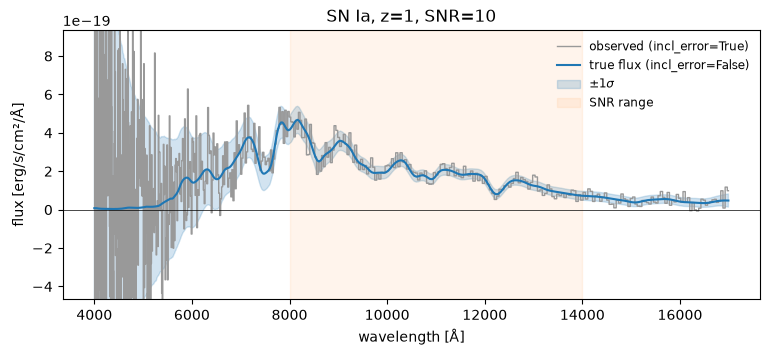

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(lbda, flux_noisy, color="0.6", lw=1, ds="steps-mid", label="observed (incl_error=True)")
ax.plot(lbda, flux_true, color="C0", lw=1.5, label="true flux (incl_error=False)")
ax.fill_between(lbda, flux_true - error, flux_true + error, color="C0", alpha=0.2, label=r"$\pm1\sigma$")

z = snia.get_properties("redshift")
ax.axvspan(4000 * (1 + z), 7000 * (1 + z), color="C1", alpha=0.08, label="SNR range")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylim(-1 * flux_true.max(), 2 * flux_true.max())  # the blue end is very noisy
ax.set(xlabel="wavelength [Å]", ylabel="flux [erg/s/cm²/Å]", title="SN Ia, z=1, SNR=10")
ax.legend(fontsize="small", frameon=False)

The variance does not depend on `incl_error`: only the flux is scattered. Each call with
`incl_error=True` gives a new noise realisation.

***
## Recap

| what | how |
|---|---|
| one-line ETC | `slicersim.lazuli_sn_etc(model, redshift, snr, ...)`, `slicersim.lazuli_etc(lbda, flux, snr, mag, band, ...)` |
| reach a SNR | `target.setup_to_snr(snr, lbda_range, frame, per_resolution)` |
| exposure time | `target.get_exposure_time(full=False)` |
| SNR in a band | `target.get_band_snr(lbda_range, frame)` |
| spectrum | `target.get_spectrum(unit, incl_error)` |

**Next:** [02 — Lazuli targets](02_lazuli_targets.ipynb)